# 03_rules.ipynb

## Chuẩn bị dữ liệu

In [2]:
%run 00_core.ipynb

In [3]:
prior_items = load_csv(PATHS.data_file("prior_items.csv"))
product_catalog = load_csv(PATHS.data_file("product_catalog.csv"))

miner = RuleMiner()
formatter = RuleFormatter(product_catalog)

## Tham số

In [4]:
settings = pd.DataFrame([
    ["Kích thước giỏ tối thiểu", CFG.min_basket_size],
    ["min_support", CFG.min_support],
    ["min_confidence", CFG.min_confidence],
    ["min_lift", CFG.min_lift],
], columns=["Tham số", "Giá trị"])

settings

,Tham số,Giá trị
0,Kích thước giỏ tối thiểu,2.000
1,min_support,0.003
2,min_confidence,0.200
3,min_lift,1.000


## Danh sách giỏ hàng

In [5]:
transactions = miner.transactions(prior_items)
transaction_summary = miner.transaction_summary(prior_items, transactions)

basket_size = prior_items.groupby("order_id")["product_id"].nunique()
valid_order_ids = basket_size[
    basket_size >= CFG.min_basket_size
].index
valid_prior_items = prior_items[
    prior_items["order_id"].isin(valid_order_ids)
].copy()

product_support = valid_prior_items.groupby("product_id")[
    "order_id"
].nunique().reset_index(name="Số giỏ chứa sản phẩm")
product_support["Support"] = (
    product_support["Số giỏ chứa sản phẩm"] / len(valid_order_ids)
).round(4)

frequent_products = product_support[
    product_support["Số giỏ chứa sản phẩm"] >= miner.min_support_count
].copy()
frequent_products["product_id"] = frequent_products["product_id"].astype(str)

catalog_for_merge = product_catalog.copy()
catalog_for_merge["product_id"] = catalog_for_merge["product_id"].astype(str)

frequent_products = frequent_products.merge(
    catalog_for_merge,
    on="product_id",
    how="left",
)
frequent_products = frequent_products.sort_values(
    "Số giỏ chứa sản phẩm",
    ascending=False,
)
frequent_products = frequent_products[
    [
        "product_id",
        "Sản phẩm",
        "Nhóm hàng chi tiết",
        "Nhóm hàng lớn",
        "Số giỏ chứa sản phẩm",
        "Support",
    ]
]

save_csv(
    frequent_products,
    PATHS.table_file("frequent_products.csv"),
)

transaction_summary

,Chỉ tiêu,Số lượng
0,Giỏ prior đủ điều kiện ban đầu,3058126
1,Sản phẩm đủ phổ biến,531
2,Giỏ còn đủ điều kiện sau lọc,2335214
3,Số giỏ tối thiểu để đạt support,9175


In [12]:
frequent_products

,product_id,Sản phẩm,Nhóm hàng chi tiết,Nhóm hàng lớn,Số giỏ chứa sản phẩm,Support
257,24852,Banana,fresh fruits,produce,470518,0.1539
124,13176,Bag of Organic Bananas,fresh fruits,produce,376676,0.1232
211,21137,Organic Strawberries,fresh fruits,produce,263563,0.0862
227,21903,Organic Baby Spinach,packaged vegetables fruits,produce,240755,0.0787
508,47209,Organic Hass Avocado,fresh fruits,produce,212887,0.0696
...,...,...,...,...,...,...
250,24221,Organic Red Grapes,fresh fruits,produce,9267,0.0030
101,10305,Black Plum,fresh fruits,produce,9260,0.0030
420,40063,Gluten Free Chocolate Chip Cookies,cookies cakes,snacks,9234,0.0030
493,46069,Supergreens!,packaged vegetables fruits,produce,9227,0.0030


## FP-Growth

In [6]:
start = perf_counter()
fpgrowth_itemsets, fpgrowth_rules = miner.mine_fpgrowth(transactions)
fpgrowth_time = perf_counter() - start
print(f"FP-Growth: {fpgrowth_time:.2f} giây")

start = perf_counter()
itemset_filter_summary = miner.closed_and_maximal(
    transactions,
    fpgrowth_itemsets,
)
print(f"Closed/Maximal: {perf_counter() - start:.2f} giây")

start = perf_counter()
top_itemsets = formatter.itemsets_table(fpgrowth_itemsets).rename(
    columns={"support": "Support"}
)
top_rules = formatter.rules_table(fpgrowth_rules).rename(
    columns={
        "support": "Support",
        "confidence": "Confidence",
        "lift": "Lift",
    }
)
print(f"Tạo bảng: {perf_counter() - start:.2f} giây")

start = perf_counter()
save_csv(itemset_filter_summary, PATHS.table_file("itemset_filter_summary.csv"))
save_csv(top_itemsets, PATHS.table_file("top_itemsets.csv"))
save_csv(top_rules, PATHS.table_file("top_rules.csv"))
save_csv(
    miner.rules_for_storage(fpgrowth_rules),
    PATHS.data_file("fpgrowth_rules.csv"),
)
print(f"Lưu file: {perf_counter() - start:.2f} giây")

FP-Growth: 6.85 giây
Closed/Maximal: 13.45 giây
Tạo bảng: 0.01 giây
Lưu file: 0.00 giây


In [7]:
top_itemsets

,Nhóm sản phẩm,Support
40,"Bag of Organic Bananas, Organic Hass Avocado",0.0204
41,"Bag of Organic Bananas, Organic Strawberries",0.0202
48,"Organic Strawberries, Banana",0.0184
55,"Banana, Organic Avocado",0.0175
58,"Organic Baby Spinach, Banana",0.0168
60,"Bag of Organic Bananas, Organic Baby Spinach",0.0165
78,"Strawberries, Banana",0.0135
79,"Banana, Large Lemon",0.0134
80,"Organic Strawberries, Organic Hass Avocado",0.0133
81,"Bag of Organic Bananas, Organic Raspberries",0.0132


In [8]:
top_rules

,Luật,Support,Confidence,Lift
0,Total 2% Lowfat Greek Strained Yogurt With Blu...,0.0031,0.4534,46.9179
1,Total 2% with Strawberry Lowfat Greek Strained...,0.0031,0.3158,46.9179
2,Lime Sparkling Water → Sparkling Water Grapefruit,0.0043,0.2942,12.3172
3,Sparkling Lemon Water → Sparkling Water Grapef...,0.0030,0.2910,12.1829
4,Bunched Cilantro → Limes,0.0041,0.2801,6.2133
5,Jalapeno Peppers → Limes,0.0037,0.2721,6.0367
6,Organic Ginger Root → Organic Garlic,0.0035,0.2102,5.9098
7,Organic Cilantro → Limes,0.0057,0.2558,5.6739
8,Organic Garlic → Organic Yellow Onion,0.0072,0.2029,5.5361
9,Raspberries → Strawberries,0.0040,0.2228,5.0073


In [9]:
itemset_filter_summary

,Loại itemset,Số lượng
0,Frequent itemsets,816
1,Closed itemsets,816
2,Maximal itemsets,717


## So sánh thuật toán

In [10]:
algorithm_comparison = miner.compare_algorithms(
    transactions,
    fp_result=(fpgrowth_itemsets, fpgrowth_rules, fpgrowth_time),
)

save_csv(
    algorithm_comparison,
    PATHS.table_file("algorithm_comparison.csv"),
)

algorithm_comparison

,Thuật toán,Số frequent itemsets,Số luật mua kèm,Thời gian chạy (giây)
0,FP-Growth,816,127,6.85
1,Apriori,816,127,4.73
2,ECLAT,816,127,6.24


## Biểu đồ chỉ số

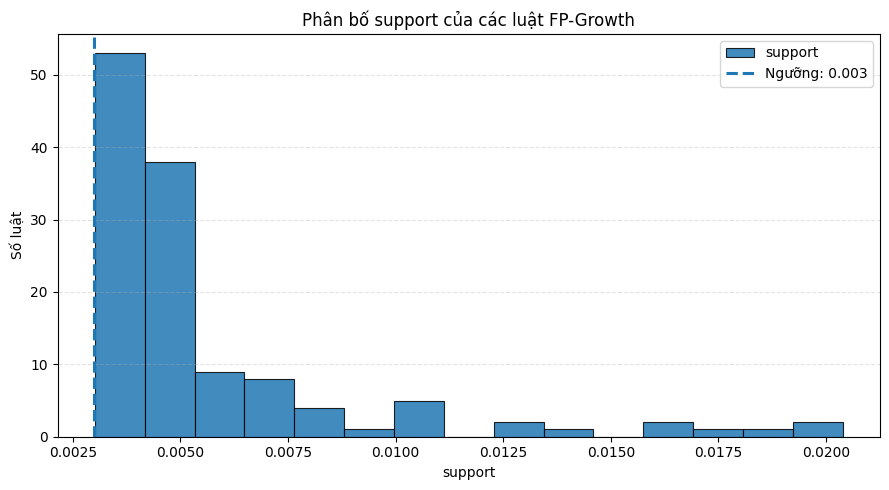

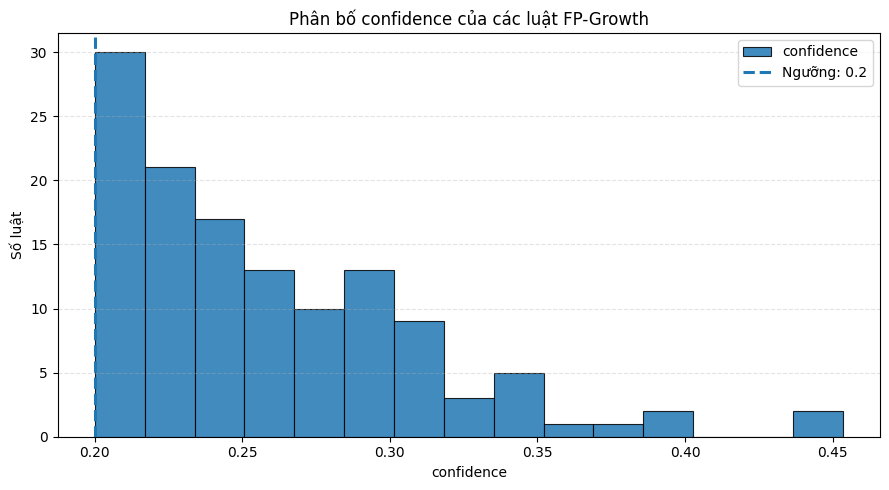

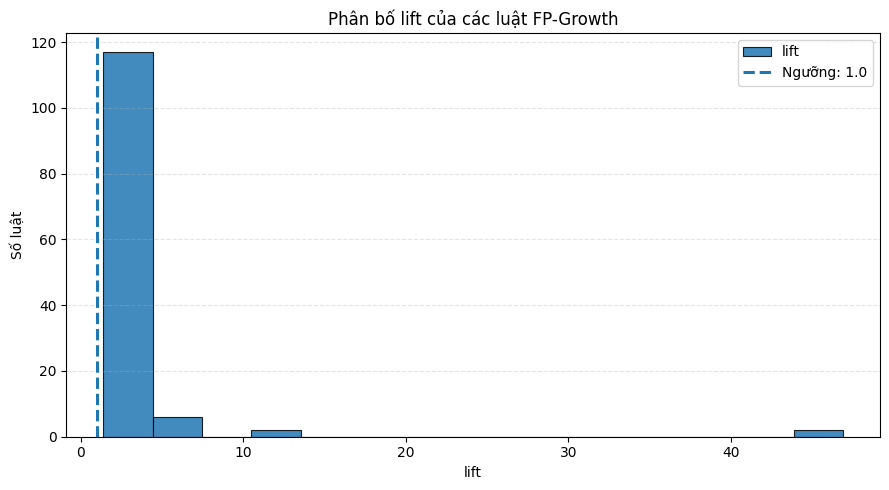

In [11]:
PLOT.histogram(
    fpgrowth_rules,
    column="support",
    title="Phân bố support của các luật FP-Growth",
    filename="support_distribution.png",
    threshold=CFG.min_support,
)

PLOT.histogram(
    fpgrowth_rules,
    column="confidence",
    title="Phân bố confidence của các luật FP-Growth",
    filename="confidence_distribution.png",
    threshold=CFG.min_confidence,
)

PLOT.histogram(
    fpgrowth_rules,
    column="lift",
    title="Phân bố lift của các luật FP-Growth",
    filename="lift_distribution.png",
    threshold=CFG.min_lift,
)